## Actividad 3_12
<div style="border-style:groove;border-width:thin;padding:10px">
Debes usar Random Forests para solucionar el ejercicio de MNIST. Recuerda que con Decision Tree llegamos al 87% de accuracy y con SVC llegamos al 98%. 
    </div>

<div style="border-style:groove;border-width:thin;padding:10px">
A continuación vamos a importar el dataset y a generar los conjuntos X e y.
    </div>

In [1]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [2]:
X, y = mnist["data"], mnist["target"]
print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


<div style="border-style:groove;border-width:thin;padding:10px">
1. Divide el dataset en el conjunto de entrenamiento y de test.
    </div>

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

<div style="border-style:groove;border-width:thin;padding:10px">
2. Crea un Random Forest con los parámetros que consideres oportuno para solucionar el problema.
    </div>

In [4]:
from sklearn.ensemble import RandomForestClassifier
rnd_clf = RandomForestClassifier(n_estimators=1000, n_jobs=-1,random_state=42,bootstrap=False)
rnd_clf.fit(X_train,y_train)

RandomForestClassifier(bootstrap=False, n_estimators=1000, n_jobs=-1,
                       random_state=42)

<div style="border-style:groove;border-width:thin;padding:10px">
3. Genera la predicción (y_pred) con el árbol entrenado y mira la precisión que has conseguido. Módifica los parámetros del árbol en el código del punto 2 para mejorar los resultados.
    </div>

In [5]:
y_pred = rnd_clf.predict(X_test)

In [6]:
from sklearn.metrics import classification_report
cr = classification_report(y_test, y_pred)
print(cr) 

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1714
           1       0.99      0.99      0.99      1977
           2       0.95      0.97      0.96      1761
           3       0.96      0.96      0.96      1806
           4       0.97      0.98      0.97      1587
           5       0.98      0.96      0.97      1607
           6       0.98      0.98      0.98      1761
           7       0.97      0.97      0.97      1878
           8       0.96      0.96      0.96      1657
           9       0.96      0.95      0.95      1752

    accuracy                           0.97     17500
   macro avg       0.97      0.97      0.97     17500
weighted avg       0.97      0.97      0.97     17500



In [7]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9706285714285714

<div style="border-style:groove;border-width:thin;padding:10px">
4. Recorre la muestra de test viendo los datos que son erróneos y muestra la imagen. Evalúa si el resultado es suficientemente bueno.
</div>

10 primeros errores


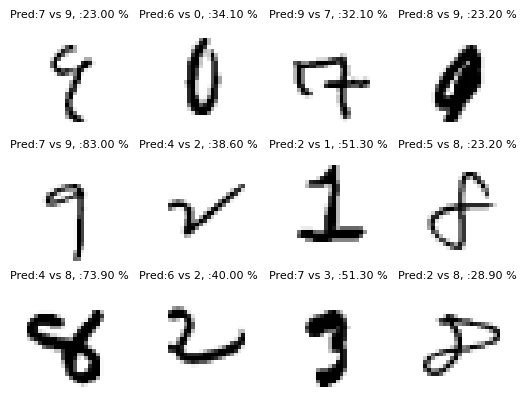

In [8]:
import numpy as np
import matplotlib.pyplot as plt
print("10 primeros errores")
y_pred_proba= rnd_clf.predict_proba(X_test)
contador = 0
for i in range(len(y_pred)):
    if y_pred[i] != y_test.to_numpy()[i]:
        digito = X_test.to_numpy()[i]
        digito_imagen = digito.reshape(28, 28)
        
        plt.subplot(3, 4, contador + 1)
        plt.imshow(digito_imagen, cmap="binary")
        plt.title(f"Pred:{y_pred[i]} vs {y_test.to_numpy()[i]}, :{y_pred_proba[i].tolist()[int(y_pred[i])]* 100:.2f} %", fontsize=8)
        plt.ylabel("Prob: ")
        plt.axis("off")
        contador += 1
        if contador == 12:
            break
plt.show()